### Feature Engineering = Deriving new features from existing onces

##### For SpaceDebrisRadar.AI using the primary orbital parameters, we get an easy way to derive such features.
-----

We will derive following features with scientific/mathematical methods

1. Orbit height (h) :
- Describes how high a satellite is above Earth.
- Used to identify orbit type
- Higher orbit = Low drag, more stable, less velocity
- Lower orbit = high drag, less stable, higher velocity

Method to derive -> Using Kepler's 3rd law  
$$
a = \left( \frac{\mu \, T^2}{4 \pi^2} \right)^{\frac{1}{3}}
$$

Where:  
- $a$ = semi-major axis (meters)  
- $\mu = 3.986 \times 10^{14} \, \mathrm{m^3/s^2}$ (Earth’s gravitational parameter)  
- $T$ = orbital period in seconds (computed as $T = \frac{86400}{\text{MEAN\_MOTION}}$)

##### So, we will need to derive first : 1. T (orbital perdiod in second)
----
### 2. Perigee and Apogee :

- **Perigee:** Closest point of the satellite’s orbit relative to Earth’s surface  
- **Apogee:** Farthest point of the satellite’s orbit relative to Earth’s surface  

These two features describe how stretched or circular the orbit is and help define orbital class and stability.

#### Why this correction?
Using the orbital formula $a (1 \pm e)$ gives the distance from **Earth’s center**.  
However, standard catalogs (e.g., SpaceTrack) report perigee/apogee as **altitudes above Earth's surface**.

So we convert orbital radius → altitude by subtracting Earth’s radius.

#### Method to derive (corrected):

1. Compute semi-major axis $a$ from Kepler's 3rd law  
2. Use eccentricity $e$ from the TLE  
3. Compute orbital radii:  
   - $r_{\text{perigee}} = a(1 - e)$  
   - $r_{\text{apogee}} = a(1 + e)$  

4. Convert orbital radii to **altitudes**:  
   - $\text{Perigee Altitude} = r_{\text{perigee}} - R_{\oplus}$  
   - $\text{Apogee Altitude} = r_{\text{apogee}} - R_{\oplus}$  

Where:  
- $a$ = semi-major axis (km)  
- $e$ = eccentricity  
- $R_{\oplus} \approx 6378 \text{ km}$ (Earth’s mean radius)

This ensures that the derived perigee/apogee match standard definitions from satellite catalogs and operational datasets.


----
3. Orbit speed (v) :
- Describes how fast a satellite is moving .
- Nearer the perigee = higher speed
- Nearer the apogee = lower speed

Method to derive -> sing semi-major axis and radius (vis-viva equation)

Formula:

v = v ≈ sqrt(μ / a)

Where:

μ = Earth’s gravitational parameter

a = semi-major axis

----
4. Age since launch (Days) :


- **Definition:** Time elapsed between the satellite’s **launch date** and the **epoch date** of the current observation.
- **Formula (conceptual):**  
  $$\text{Age (days)} = \text{Epoch Date} - \text{Launch Date}$$
- **Why it matters:**  
  - Satellites degrade over time due to **orbital decay**, **space weather**, or **mechanical aging**.  
  - Useful for **anomaly detection** or understanding expected orbital behavior.
- **Units:** Typically **days**, but can also convert to **years** for readability.
- **Prototype use:** Can be added as a **numerical feature** for clustering or ML models.
----
5. Satellite Type

- **Definition:** The **type or sequence of the satellite** within a launch, extracted from the last character of the `OBJECT_ID`.  
- **How it’s extracted:**  
  - `OBJECT_ID` format: `YYYY-NNN[A-Z]`  
    - `YYYY` → launch year  
    - `NNN` → launch number of that year  
    - `[A-Z]` → satellite type / sequence (A = primary payload, B/C... = secondary payloads)  
- **Why it matters:**  
  - Satellites of the same launch can behave differently; primary payloads may have **different orbit characteristics** than secondary or experimental satellites.  
  - Useful as a **categorical feature** for clustering or anomaly detection.  
- **Prototype use:** Can be added as a **categorical feature** to help ML models distinguish satellite roles within the same launch.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Important thorughout this project
%matplotlib inline


In [2]:
df = pd.read_csv('../data/02_cleaned/satellites_cleaned.csv')

In [3]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT
0,CALSPHERE 1,1964-063C,2025-12-04T15:36:43.212960,13.763517,0.002716,90.2215,67.2697,159.0699,309.0581,0,U,900,999,4466,0.001228,1.211000e-05,0.0
1,CALSPHERE 2,1964-063E,2025-12-04T14:12:30.284352,13.528817,0.002040,90.2363,71.2062,74.4339,353.0789,0,U,902,999,82995,0.000097,7.400000e-07,0.0
2,LCS 1,1965-034C,2025-12-04T11:40:34.858848,9.893095,0.001344,32.1426,279.3197,153.3358,206.7832,0,U,1361,999,19060,0.001319,1.800000e-07,0.0
3,TEMPSAT 1,1965-065E,2025-12-04T15:49:06.875904,13.335813,0.007139,89.9887,212.6762,75.2749,339.0456,0,U,1512,999,93412,0.000160,8.900000e-07,0.0
4,CALSPHERE 4A,1965-065H,2025-12-04T16:19:00.877728,13.362372,0.006822,89.9093,124.3111,292.9140,93.8021,0,U,1520,999,93673,0.000319,1.750000e-06,0.0


In [4]:
len(df)

13551

#### 1. Let's compute Orbit height (h) in Kilometers

- Compute orbital period in seconds
- It tells that in average, how much time (in seconds) does a satellite takes to orbit around the Earth

In [5]:
df['ORBIT_PERIOD_SEC'] = 86400 / df['MEAN_MOTION']

In [6]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC
0,CALSPHERE 1,1964-063C,2025-12-04T15:36:43.212960,13.763517,0.002716,90.2215,67.2697,159.0699,309.0581,0,U,900,999,4466,0.001228,1.211000e-05,0.0,6277.465223
1,CALSPHERE 2,1964-063E,2025-12-04T14:12:30.284352,13.528817,0.002040,90.2363,71.2062,74.4339,353.0789,0,U,902,999,82995,0.000097,7.400000e-07,0.0,6386.367527
2,LCS 1,1965-034C,2025-12-04T11:40:34.858848,9.893095,0.001344,32.1426,279.3197,153.3358,206.7832,0,U,1361,999,19060,0.001319,1.800000e-07,0.0,8733.364470
3,TEMPSAT 1,1965-065E,2025-12-04T15:49:06.875904,13.335813,0.007139,89.9887,212.6762,75.2749,339.0456,0,U,1512,999,93412,0.000160,8.900000e-07,0.0,6478.795009
4,CALSPHERE 4A,1965-065H,2025-12-04T16:19:00.877728,13.362372,0.006822,89.9093,124.3111,292.9140,93.8021,0,U,1520,999,93673,0.000319,1.750000e-06,0.0,6465.917684


 - Compute Earth’s gravitational parameter

In [7]:
# Gravitational constant (G) in N m^2/kg^2
G = 6.67430e-11 

# Mass of Earth (M_E) in kg
M_earth = 5.972e24 

# Calculate Earth's gravitational parameter in m^3/s^2
mu_earth_calculated = G * M_earth  # in meters

In [8]:
mu_earth_calculated

398589196000000.0

- Compute Semi major axis for each satelite (in KM)

In [9]:
df['SEMI_MAJOR_AXIS'] = ((mu_earth_calculated * df['ORBIT_PERIOD_SEC'] ** 2 ) / (4*math.pi**2)) **(1/3) / 1000

In [10]:
df['SEMI_MAJOR_AXIS']

0        7354.923145
1        7439.741868
2        9165.925408
3        7511.351540
4        7501.395143
            ...     
13546    6966.553000
13547    6966.380362
13548    6796.828033
13549    6950.187425
13550    7139.843854
Name: SEMI_MAJOR_AXIS, Length: 13551, dtype: float64

- Lastly, subtract semi mejor axis with Earth's radius to get orbital height (h)

In [11]:
df['ORBIT_HEIGHT'] = df['SEMI_MAJOR_AXIS'] -  6371

In [12]:
df['ORBIT_HEIGHT']

0         983.923145
1        1068.741868
2        2794.925408
3        1140.351540
4        1130.395143
            ...     
13546     595.553000
13547     595.380362
13548     425.828033
13549     579.187425
13550     768.843854
Name: ORBIT_HEIGHT, Length: 13551, dtype: float64

In [13]:
df['ORBIT_HEIGHT'].describe()

count    13551.000000
mean      2431.429056
std       7746.507273
min        155.553595
25%        482.283482
50%        546.793176
75%        579.040502
max      91394.290330
Name: ORBIT_HEIGHT, dtype: float64

---
#### Since our project is about Low Earth Orbit, we can now easiy filter those satellites (orbital height >=160 & orbtial height <=2000)

In [14]:
# before row count : 
df.shape

(13551, 20)

In [15]:
df = df[(df['ORBIT_HEIGHT'] >=160) & (df['ORBIT_HEIGHT'] <=2000)]

In [16]:
df.shape

(12747, 20)

----
#### 2. Let's compute Perigee and Apogee

In [17]:
# Perigee altitude = a * (1 - e) - Earth_radius
df['PERIGEE'] = df['SEMI_MAJOR_AXIS'] * (1 - df['ECCENTRICITY']) - 6378

# Apogee altitude = a * (1 + e) - Earth_radius
df['APOGEE'] = df['SEMI_MAJOR_AXIS'] * (1 + df['ECCENTRICITY']) - 6378


In [18]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE
0,CALSPHERE 1,1964-063C,2025-12-04T15:36:43.212960,13.763517,0.002716,90.2215,67.2697,159.0699,309.0581,0,...,999,4466,0.001228,1.211000e-05,0.0,6277.465223,7354.923145,983.923145,956.945702,996.900587
1,CALSPHERE 2,1964-063E,2025-12-04T14:12:30.284352,13.528817,0.002040,90.2363,71.2062,74.4339,353.0789,0,...,999,82995,0.000097,7.400000e-07,0.0,6386.367527,7439.741868,1068.741868,1046.564050,1076.919685
3,TEMPSAT 1,1965-065E,2025-12-04T15:49:06.875904,13.335813,0.007139,89.9887,212.6762,75.2749,339.0456,0,...,999,93412,0.000160,8.900000e-07,0.0,6478.795009,7511.351540,1140.351540,1079.728002,1186.975079
4,CALSPHERE 4A,1965-065H,2025-12-04T16:19:00.877728,13.362372,0.006822,89.9093,124.3111,292.9140,93.8021,0,...,999,93673,0.000319,1.750000e-06,0.0,6465.917684,7501.395143,1130.395143,1072.218375,1174.571911
5,OPS 5712 (P/L 160),1967-053A,2025-12-04T16:45:34.701120,14.739996,0.000504,69.9162,153.7607,291.0755,68.9852,0,...,999,3753,0.003397,2.236400e-04,0.0,5861.602644,7026.399599,655.399599,644.855483,651.943715


----
#### 3. Let's compute Orbit speed (v)

In [19]:
# Since we can see that the Eccentricity for LEO satellites is barly big (max 0.1), v ≈ sqrt(μ / a) is enough to calcualte the
# orbital speed (which might be mostly / should be constant enough throughout the orbit for each indivisual satellite)
df.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE
count,12747.000000,12747.000000,12747.000000,12747.000000,12747.000000,12747.000000,12747.0,12747.000000,12747.0,12747.000000,12747.000000,12747.000000,12747.000000,12747.000000,12747.000000,12747.000000,12747.000000,12747.000000
mean,15.016915,0.000534,62.005631,173.485947,162.469309,197.118171,0.0,57053.969326,999.0,13374.579823,0.000305,0.000105,0.000023,5764.286354,6946.886902,575.886902,565.093693,572.680110
std,0.617993,0.003063,20.680190,106.721927,94.421337,94.931313,0.0,7507.881894,0.0,13272.102541,0.005861,0.003169,0.001773,262.270391,207.136722,207.136722,205.385616,211.330150
min,11.826701,0.000004,0.046300,0.009100,0.132100,0.206700,0.0,900.000000,999.0,2.000000,-0.197780,-0.094059,-0.000001,5319.178353,6585.947995,214.947995,144.577935,212.127784
25%,15.025374,0.000124,43.005300,74.038150,87.204800,93.084700,0.0,53002.500000,999.0,4016.000000,0.000069,0.000005,0.000000,5646.295431,6853.267136,482.267136,474.403632,476.130392
50%,15.088541,0.000151,53.160400,171.288400,106.342200,252.774300,0.0,58450.000000,999.0,10679.000000,0.000247,0.000030,0.000000,5726.199637,6917.772126,546.772126,538.658498,540.687868
75%,15.302069,0.000282,86.397500,266.266700,267.066200,272.944050,0.0,63077.500000,999.0,18442.500000,0.001231,0.000332,0.000000,5750.272846,6937.146989,566.146989,558.381916,560.082487
max,16.243110,0.164554,139.339400,359.938200,359.889800,359.972100,0.0,66877.000000,999.0,99911.000000,0.105120,0.094978,0.158408,7305.502802,8137.456309,1766.456309,1745.075796,2872.095737


In [20]:
# Constants
mu_earth = 3.986e5  # km^3/s^2
R_earth = 6371  # km


# Orbital speed (km/s)
df['ORBITAL_SPEED'] = np.sqrt(mu_earth / df['SEMI_MAJOR_AXIS'])

In [21]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
0,CALSPHERE 1,1964-063C,2025-12-04T15:36:43.212960,13.763517,0.002716,90.2215,67.2697,159.0699,309.0581,0,...,4466,0.001228,1.211000e-05,0.0,6277.465223,7354.923145,983.923145,956.945702,996.900587,7.361725
1,CALSPHERE 2,1964-063E,2025-12-04T14:12:30.284352,13.528817,0.002040,90.2363,71.2062,74.4339,353.0789,0,...,82995,0.000097,7.400000e-07,0.0,6386.367527,7439.741868,1068.741868,1046.564050,1076.919685,7.319640
3,TEMPSAT 1,1965-065E,2025-12-04T15:49:06.875904,13.335813,0.007139,89.9887,212.6762,75.2749,339.0456,0,...,93412,0.000160,8.900000e-07,0.0,6478.795009,7511.351540,1140.351540,1079.728002,1186.975079,7.284665
4,CALSPHERE 4A,1965-065H,2025-12-04T16:19:00.877728,13.362372,0.006822,89.9093,124.3111,292.9140,93.8021,0,...,93673,0.000319,1.750000e-06,0.0,6465.917684,7501.395143,1130.395143,1072.218375,1174.571911,7.289498
5,OPS 5712 (P/L 160),1967-053A,2025-12-04T16:45:34.701120,14.739996,0.000504,69.9162,153.7607,291.0755,68.9852,0,...,3753,0.003397,2.236400e-04,0.0,5861.602644,7026.399599,655.399599,644.855483,651.943715,7.531860


In [22]:
df.describe()

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
count,12747.000000,12747.000000,12747.000000,12747.000000,12747.000000,12747.000000,12747.0,12747.000000,12747.0,12747.000000,12747.000000,12747.000000,12747.000000,12747.000000,12747.000000,12747.000000,12747.000000,12747.000000,12747.000000
mean,15.016915,0.000534,62.005631,173.485947,162.469309,197.118171,0.0,57053.969326,999.0,13374.579823,0.000305,0.000105,0.000023,5764.286354,6946.886902,575.886902,565.093693,572.680110,7.577229
std,0.617993,0.003063,20.680190,106.721927,94.421337,94.931313,0.0,7507.881894,0.0,13272.102541,0.005861,0.003169,0.001773,262.270391,207.136722,207.136722,205.385616,211.330150,0.107406
min,11.826701,0.000004,0.046300,0.009100,0.132100,0.206700,0.0,900.000000,999.0,2.000000,-0.197780,-0.094059,-0.000001,5319.178353,6585.947995,214.947995,144.577935,212.127784,6.998812
25%,15.025374,0.000124,43.005300,74.038150,87.204800,93.084700,0.0,53002.500000,999.0,4016.000000,0.000069,0.000005,0.000000,5646.295431,6853.267136,482.267136,474.403632,476.130392,7.580157
50%,15.088541,0.000151,53.160400,171.288400,106.342200,252.774300,0.0,58450.000000,999.0,10679.000000,0.000247,0.000030,0.000000,5726.199637,6917.772126,546.772126,538.658498,540.687868,7.590765
75%,15.302069,0.000282,86.397500,266.266700,267.066200,272.944050,0.0,63077.500000,999.0,18442.500000,0.001231,0.000332,0.000000,5750.272846,6937.146989,566.146989,558.381916,560.082487,7.626404
max,16.243110,0.164554,139.339400,359.938200,359.889800,359.972100,0.0,66877.000000,999.0,99911.000000,0.105120,0.094978,0.158408,7305.502802,8137.456309,1766.456309,1745.075796,2872.095737,7.779640


In [23]:
df[df['ORBIT_HEIGHT'] == df['ORBIT_HEIGHT'].max()]

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
376,GLOBALSTAR M077,2010-054D,2025-12-02T07:13:08.726016,11.826701,0.001767,52.0116,319.4726,313.8474,152.676,0,...,69812,0.000035,-7.900000e-07,0.0,7305.502802,8137.456309,1766.456309,1745.075796,1773.836821,6.998812


----
#### 4. Let's find approximate age since launch

In [24]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED
0,CALSPHERE 1,1964-063C,2025-12-04T15:36:43.212960,13.763517,0.002716,90.2215,67.2697,159.0699,309.0581,0,...,4466,0.001228,1.211000e-05,0.0,6277.465223,7354.923145,983.923145,956.945702,996.900587,7.361725
1,CALSPHERE 2,1964-063E,2025-12-04T14:12:30.284352,13.528817,0.002040,90.2363,71.2062,74.4339,353.0789,0,...,82995,0.000097,7.400000e-07,0.0,6386.367527,7439.741868,1068.741868,1046.564050,1076.919685,7.319640
3,TEMPSAT 1,1965-065E,2025-12-04T15:49:06.875904,13.335813,0.007139,89.9887,212.6762,75.2749,339.0456,0,...,93412,0.000160,8.900000e-07,0.0,6478.795009,7511.351540,1140.351540,1079.728002,1186.975079,7.284665
4,CALSPHERE 4A,1965-065H,2025-12-04T16:19:00.877728,13.362372,0.006822,89.9093,124.3111,292.9140,93.8021,0,...,93673,0.000319,1.750000e-06,0.0,6465.917684,7501.395143,1130.395143,1072.218375,1174.571911,7.289498
5,OPS 5712 (P/L 160),1967-053A,2025-12-04T16:45:34.701120,14.739996,0.000504,69.9162,153.7607,291.0755,68.9852,0,...,3753,0.003397,2.236400e-04,0.0,5861.602644,7026.399599,655.399599,644.855483,651.943715,7.531860


In [25]:
# Convert Epoch to pandas DateTime object
df['EPOCH'] = pd.to_datetime(df['EPOCH'])


df['AGE_SINCE_LAUNCH'] = round(
    df['EPOCH'].dt.year + df['EPOCH'].dt.dayofyear / 365.25 - df['OBJECT_ID'].str.split('-').str[0].astype(int), 3
)

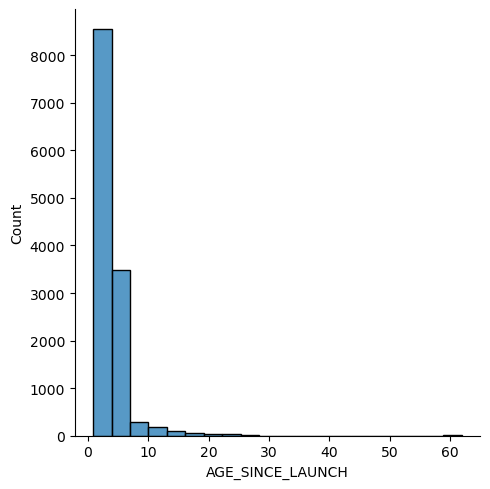

In [26]:
sns.displot(data=df, x = 'AGE_SINCE_LAUNCH', bins = 20)

In [27]:
df.head()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH
0,CALSPHERE 1,1964-063C,2025-12-04 15:36:43.212960,13.763517,0.002716,90.2215,67.2697,159.0699,309.0581,0,...,0.001228,1.211000e-05,0.0,6277.465223,7354.923145,983.923145,956.945702,996.900587,7.361725,61.925
1,CALSPHERE 2,1964-063E,2025-12-04 14:12:30.284352,13.528817,0.002040,90.2363,71.2062,74.4339,353.0789,0,...,0.000097,7.400000e-07,0.0,6386.367527,7439.741868,1068.741868,1046.564050,1076.919685,7.319640,61.925
3,TEMPSAT 1,1965-065E,2025-12-04 15:49:06.875904,13.335813,0.007139,89.9887,212.6762,75.2749,339.0456,0,...,0.000160,8.900000e-07,0.0,6478.795009,7511.351540,1140.351540,1079.728002,1186.975079,7.284665,60.925
4,CALSPHERE 4A,1965-065H,2025-12-04 16:19:00.877728,13.362372,0.006822,89.9093,124.3111,292.9140,93.8021,0,...,0.000319,1.750000e-06,0.0,6465.917684,7501.395143,1130.395143,1072.218375,1174.571911,7.289498,60.925
5,OPS 5712 (P/L 160),1967-053A,2025-12-04 16:45:34.701120,14.739996,0.000504,69.9162,153.7607,291.0755,68.9852,0,...,0.003397,2.236400e-04,0.0,5861.602644,7026.399599,655.399599,644.855483,651.943715,7.531860,58.925


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12747 entries, 0 to 13550
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   OBJECT_NAME          12747 non-null  object        
 1   OBJECT_ID            12747 non-null  object        
 2   EPOCH                12747 non-null  datetime64[ns]
 3   MEAN_MOTION          12747 non-null  float64       
 4   ECCENTRICITY         12747 non-null  float64       
 5   INCLINATION          12747 non-null  float64       
 6   RA_OF_ASC_NODE       12747 non-null  float64       
 7   ARG_OF_PERICENTER    12747 non-null  float64       
 8   MEAN_ANOMALY         12747 non-null  float64       
 9   EPHEMERIS_TYPE       12747 non-null  int64         
 10  CLASSIFICATION_TYPE  12747 non-null  object        
 11  NORAD_CAT_ID         12747 non-null  int64         
 12  ELEMENT_SET_NO       12747 non-null  int64         
 13  REV_AT_EPOCH         12747 non-null 

----
#### 5. Let's find what type of satellite part it it

In [29]:
# This information is stored as the last digit in the OBJECT_ID column
df['OBJECT_ID']

0        1964-063C
1        1964-063E
3        1965-065E
4        1965-065H
5        1967-053A
           ...    
13546    2025-274M
13547    2025-274N
13548    2025-275A
13549    2025-279A
13550    2025-282A
Name: OBJECT_ID, Length: 12747, dtype: object

In [30]:
# capture anything A-Z as a group
df['SAT_TYPE'] = df['OBJECT_ID'].str.extract(r'([A-Z])$')

In [31]:
df['SAT_TYPE'].value_counts()

SAT_TYPE
A    1211
B     885
C     818
D     720
E     667
F     573
G     539
H     535
J     520
K     505
L     486
M     469
N     458
R     441
Q     440
P     440
V     429
S     423
T     420
U     415
W     407
X     367
Y     320
Z     259
Name: count, dtype: int64

In [32]:
df.tail()

,OBJECT_NAME,OBJECT_ID,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,...,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH,SAT_TYPE
13546,SNUGLITE-III,2025-274M,2025-12-04 13:27:54.573120,14.930341,0.001368,97.7386,265.9163,312.7426,47.2642,0,...,0.000054,0.000000,5786.873984,6966.553000,595.553000,579.025542,598.080458,7.564142,0.925,M
13547,2025-274N,2025-274N,2025-12-04 08:37:53.431680,14.930896,0.001410,97.7387,265.7189,312.6803,47.3228,0,...,0.000040,0.000000,5786.658879,6966.380362,595.380362,578.557766,598.202958,7.564236,0.925,N
13548,SOYUZ-MS 28,2025-275A,2025-12-04 13:02:29.700384,15.493060,0.000360,51.6299,183.0583,202.7086,157.3744,0,...,0.000159,0.000000,5576.690341,6796.828033,425.828033,416.383893,421.272172,7.658003,0.925,A
13549,KOMPSAT-7,2025-279A,2025-12-01 20:35:16.060992,14.983106,0.000975,97.6394,281.9587,255.3935,104.6207,0,...,0.000009,0.000000,5766.494491,6950.187425,579.187425,565.410923,578.963927,7.573042,0.917,A
13550,DUMMY PAYLOAD,2025-282A,2025-12-04 16:11:05.422848,14.390092,0.086454,56.9559,88.0896,206.2177,149.2529,0,...,0.011237,0.000007,6004.131259,7139.843854,768.843854,144.577935,1379.109772,7.471784,0.925,A


---
Correliation : (help up to check if according to physics our features are consistent (except anomalies!))

In [33]:
df.corr(numeric_only=True)

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH
MEAN_MOTION,1.000000,-0.128014,-0.368557,-0.055647,0.149198,-0.144521,NaN,0.349326,NaN,-0.315882,-0.008528,0.026269,0.021408,-0.998350,-0.998851,-0.998851,-0.992737,-0.993250,0.999815,-0.298520
ECCENTRICITY,-0.128014,1.000000,0.091231,-0.008457,-0.007663,0.008679,NaN,-0.143899,NaN,0.149390,0.005417,0.022307,0.005680,0.126890,0.127110,0.127110,0.017692,0.231981,-0.127693,0.184467
INCLINATION,-0.368557,0.091231,1.000000,-0.148730,-0.211796,0.210194,NaN,-0.225275,NaN,0.245075,0.047983,0.035156,-0.008311,0.364681,0.365446,0.365446,0.358949,0.367537,-0.367458,0.226726
RA_OF_ASC_NODE,-0.055647,-0.008457,-0.148730,1.000000,-0.012342,-0.003493,NaN,-0.000927,NaN,-0.002349,0.031345,0.020540,0.012198,0.055547,0.055579,0.055579,0.056836,0.053716,-0.055639,0.003082
ARG_OF_PERICENTER,0.149198,-0.007663,-0.211796,-0.012342,1.000000,-0.938076,NaN,0.145045,NaN,-0.112989,-0.042536,-0.023681,0.002159,-0.150721,-0.150521,-0.150521,-0.150704,-0.148605,0.149790,-0.088624
MEAN_ANOMALY,-0.144521,0.008679,0.210194,-0.003493,-0.938076,1.000000,NaN,-0.135062,NaN,0.106582,0.013407,0.009439,-0.002047,0.145340,0.145259,0.145259,0.145282,0.143558,-0.144881,0.080664
EPHEMERIS_TYPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NORAD_CAT_ID,0.349326,-0.143899,-0.225275,-0.000927,0.145045,-0.135062,NaN,1.000000,NaN,-0.860944,-0.056973,-0.055324,0.012519,-0.342093,-0.343317,-0.343317,-0.330452,-0.351853,0.346949,-0.861077
ELEMENT_SET_NO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
REV_AT_EPOCH,-0.315882,0.149390,0.245075,-0.002349,-0.112989,0.106582,NaN,-0.860944,NaN,1.000000,0.027022,0.024894,-0.010106,0.307855,0.309185,0.309185,0.295363,0.319045,-0.313200,0.760176


----
###  Remove irrelevent features
- We will now remove those features that will NOT be used in any of the ML models AND are not relevant to our task, that are :
         
1. OBJECT_ID            
2. EPHEMERIS_TYPE   (all have just a single value : 11990)    
3. CLASSIFICATION_TYPE (all have just a single value : U)
4. ELEMENT_SET_NO  (unique identifier)


In [34]:
df = df.drop(columns=['OBJECT_ID',  'EPHEMERIS_TYPE', 'CLASSIFICATION_TYPE',  'ELEMENT_SET_NO'])

#### Save the featured data

In [35]:
df.to_csv('../data/03_engineered/satellites_engineered.csv', index=False)

In [36]:
df.head()

,OBJECT_NAME,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,NORAD_CAT_ID,REV_AT_EPOCH,...,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ORBIT_PERIOD_SEC,SEMI_MAJOR_AXIS,ORBIT_HEIGHT,PERIGEE,APOGEE,ORBITAL_SPEED,AGE_SINCE_LAUNCH,SAT_TYPE
0,CALSPHERE 1,2025-12-04 15:36:43.212960,13.763517,0.002716,90.2215,67.2697,159.0699,309.0581,900,4466,...,1.211000e-05,0.0,6277.465223,7354.923145,983.923145,956.945702,996.900587,7.361725,61.925,C
1,CALSPHERE 2,2025-12-04 14:12:30.284352,13.528817,0.002040,90.2363,71.2062,74.4339,353.0789,902,82995,...,7.400000e-07,0.0,6386.367527,7439.741868,1068.741868,1046.564050,1076.919685,7.319640,61.925,E
3,TEMPSAT 1,2025-12-04 15:49:06.875904,13.335813,0.007139,89.9887,212.6762,75.2749,339.0456,1512,93412,...,8.900000e-07,0.0,6478.795009,7511.351540,1140.351540,1079.728002,1186.975079,7.284665,60.925,E
4,CALSPHERE 4A,2025-12-04 16:19:00.877728,13.362372,0.006822,89.9093,124.3111,292.9140,93.8021,1520,93673,...,1.750000e-06,0.0,6465.917684,7501.395143,1130.395143,1072.218375,1174.571911,7.289498,60.925,H
5,OPS 5712 (P/L 160),2025-12-04 16:45:34.701120,14.739996,0.000504,69.9162,153.7607,291.0755,68.9852,2826,3753,...,2.236400e-04,0.0,5861.602644,7026.399599,655.399599,644.855483,651.943715,7.531860,58.925,A


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12747 entries, 0 to 13550
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   OBJECT_NAME        12747 non-null  object        
 1   EPOCH              12747 non-null  datetime64[ns]
 2   MEAN_MOTION        12747 non-null  float64       
 3   ECCENTRICITY       12747 non-null  float64       
 4   INCLINATION        12747 non-null  float64       
 5   RA_OF_ASC_NODE     12747 non-null  float64       
 6   ARG_OF_PERICENTER  12747 non-null  float64       
 7   MEAN_ANOMALY       12747 non-null  float64       
 8   NORAD_CAT_ID       12747 non-null  int64         
 9   REV_AT_EPOCH       12747 non-null  int64         
 10  BSTAR              12747 non-null  float64       
 11  MEAN_MOTION_DOT    12747 non-null  float64       
 12  MEAN_MOTION_DDOT   12747 non-null  float64       
 13  ORBIT_PERIOD_SEC   12747 non-null  float64       
 14  SEMI_MAJOR_